In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

In [2]:
folder_path = Path("C:/Users/ezra/OneDrive - Delft University of Technology/School/Universiteit/BEP/Raw Data")

# Create a dictionary mapping filename -> full path
file_dict = {
    f.name: str(f.resolve()) for f in folder_path.iterdir() if f.is_file()
}
key_list = list(file_dict.keys())
print(file_dict.keys())

dict_keys(['2026-06-19 - TN binnen 2.txt', '2026-06-19 - TN binnen.txt', '2026-06-22 - TN binnen.txt', '2026-06-23 12.25 - GV.txt', '2026-06-24 16.52 - GV.txt', '2026-06-29 09.45 - GV 14.45End.txt', '2026-06-30 00.10 - GV - 2e diode stuk.txt', '2026-07-02 14.51 - GV.txt', 'log_000.txt', 'log_001.txt', 'log_004.txt', 'log_20260709_1236.txt', 'log_20260709_1632_0.txt', 'log_20260713_1253.txt', 'log_20260714_0903.txt', 'log_20260714_1650_0_test.txt', 'log_20260714_1655_0_test.txt', 'log_20260714_1721_test.txt', 'log_20260714_1729_test.txt', 'log_20260714_1744_0_test.txt', 'log_20260714_1756_0_test.txt', 'log_20260714_1757_test.txt', 'log_20260714_1806_test.txt', 'log_20260715_1228_test.txt', 'log_20260715_1325_testbox.txt', 'log_20260715_1513_testbox.txt', 'log_20260715_1556_first_v5.txt'])


In [134]:
filenumber = 12
print(key_list[filenumber])
data = np.loadtxt(fname = file_dict[key_list[filenumber]], usecols = (1,2,3,4,5,6), skiprows=1,delimiter=',')

log_20260709_1632_0.txt


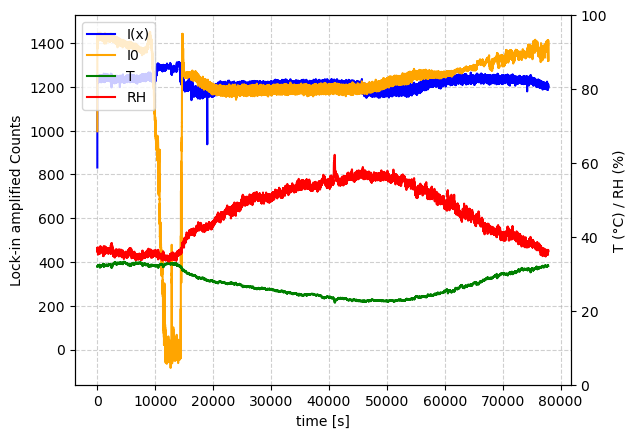

In [136]:
# Create the main plot and the first y-axis
fig, ax1 = plt.subplots()

# Plot I(x) and I0 on the left y-axis
line1 = ax1.plot(data[:,0], label='I(x)', color='blue')
line2 = ax1.plot(data[:,1], label='I0', color='orange')
ax1.set_ylabel('Lock-in amplified Counts') # Customize this label as needed

# --- ADDED GRID HERE ---
# Using a dashed line and lower alpha (opacity) keeps it from overpowering your data
ax1.grid(True, linestyle='--', alpha=0.6) 

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot T and RH on the right y-axis (removing the *30 multiplier since we have the 0-100 scale)
line3 = ax2.plot(data[:,2], label='T', color='green')
line4 = ax2.plot(data[:,3], label='RH', color='red')
ax2.set_ylabel('T (°C) / RH (%)')
ax2.set_ylim(0, 100) # Set the range from 0 to 100

# Combine legends from both axes
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
ax1.set_xlabel('time [s]')
plt.show()

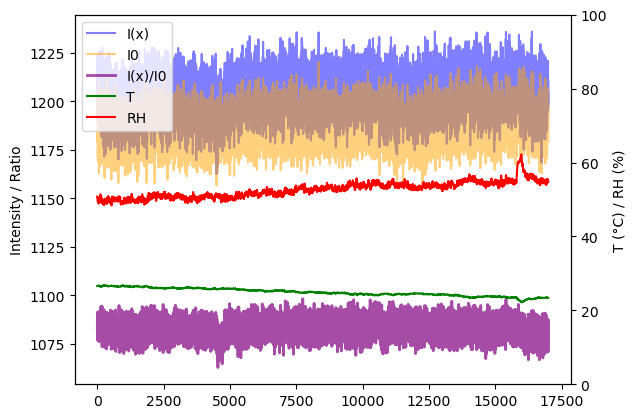

In [152]:
xmin,xmax = 0,np.size(data[:,0])

#xmin,xmax = 110,320
xmin,xmax = 25000,42000
#xmin,xmax = 1800,6000

# 1. Slice the data to your window of interest FIRST
data_window = data[xmin:xmax]

# 2. Extract your variables from the window
Ix = data_window[:, 0]
I0 = data_window[:, 1]
T = data_window[:, 2]
RH = data_window[:, 3]

# 3. Calculate ratio safely
ratio = np.divide(Ix, I0, out=np.zeros_like(Ix), where=I0 > 0)

# Create mask: True for good data, False for data to clip
valid_mask = (np.abs(ratio - np.median(ratio)) <= 1.5) & (ratio != 0)  # Use '&' for element-wise logical AND

# 4. Apply the mask to ALL variables (True elements are kept, False are dropped)
Ix_clipped = Ix[valid_mask]
I0_clipped = I0[valid_mask]
ratio_clipped = ratio[valid_mask]
T_clipped = T[valid_mask]
RH_clipped = RH[valid_mask]

# --- Plotting ---
fig, ax1 = plt.subplots()

# Left Y-Axis: Intensities and Ratio (All clipped & perfectly aligned)
line1 = ax1.plot(Ix_clipped, label='I(x)', color='blue', alpha=0.5)
line2 = ax1.plot(I0_clipped, label='I0', color='orange', alpha=0.5)
line3 = ax1.plot(ratio_clipped * 0.9 * np.mean(I0_clipped), label='I(x)/I0', color='purple', linewidth=2, alpha=0.7)
ax1.set_ylabel('Intensity / Ratio')

# Right Y-Axis: Weather Data
ax2 = ax1.twinx()
line4 = ax2.plot(T_clipped, label='T', color='green')
line5 = ax2.plot(RH_clipped, label='RH', color='red')
ax2.set_ylabel('T (°C) / RH (%)')
ax2.set_ylim(0, 100)

# Combine legends
lines = line1 + line2 + line3 + line4 + line5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()

Theoretical slope: 3.1285754480540477e-07
Data slope: 3.8111087075349835e-08
6.3194398370229744e-09 6.202227859678683e-05


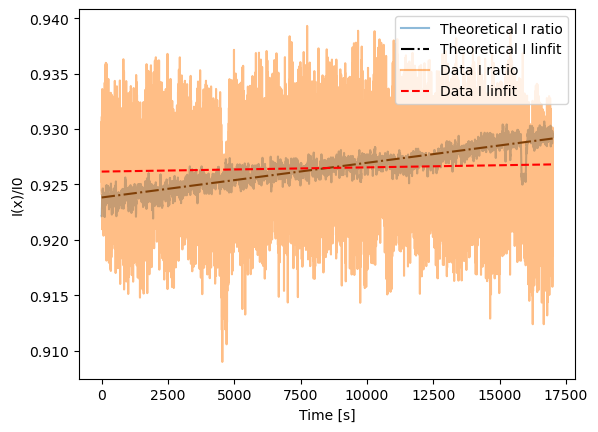

In [154]:
def Molarsat(T): #saturation molarity at T[K]
    R = 8.314
    return 611.21/R/(T+273.15)*np.exp((18.678 - T/234.5 )*( T/(257.14 + T)))
    
def Absorption_coef(M_s,alpha_h2o,x,RH): #absorption coefficient in a natural exponential
    return M_s*alpha_h2o*x*RH

def linfit(x,a,b):
    return a*x+b


M_s = Molarsat(T_clipped)
alpha_h2o = 4.7/(101325/8.314/296)
x = 1
t_arr = np.arange(0,np.size(T_clipped))

I_ratio = np.exp(-Absorption_coef(M_s,alpha_h2o,x,RH_clipped/100))
ratio_sc = ratio_clipped/np.mean(ratio_clipped)*np.mean(I_ratio)

var_data,cov_data = curve_fit(linfit,t_arr,ratio_sc)
var_theoretical,cov_theoretical = curve_fit(linfit,t_arr,I_ratio)



plt.plot(I_ratio, alpha = 0.5, label = 'Theoretical I ratio')
plt.plot(linfit(t_arr,*var_theoretical), 'k-.', alpha = 1, label = 'Theoretical I linfit')
plt.plot(ratio_sc, alpha = 0.5, label = 'Data I ratio')
plt.plot(linfit(t_arr,*var_data), 'r--', alpha = 1, label = 'Data I linfit')

plt.xlabel('Time [s]')
plt.ylabel('I(x)/I0')
plt.legend(loc = 'upper right')

print('Theoretical slope:', var_theoretical[0])
print('Data slope:', var_data[0])
print(np.sqrt(cov_data[0,0]),np.sqrt(cov_data[1,1]))

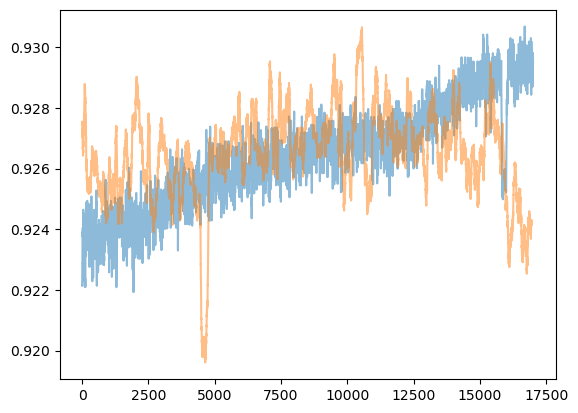

In [156]:
def Molarsat(T): #saturation molarity at T[K]
    R = 8.314
    return 611.21/R/(T+273.15)*np.exp((18.678 - T/234.5 )*( T/(257.14 + T)))
    
def Absorption_coef(M_s,alpha_h2o,x,RH): #absorption coefficient in a natural exponential
    return M_s*alpha_h2o*x*RH

def rolling_average(data, n):
    """
    Computes the rolling average over n points and clips incomplete edge windows.
    """
    # Create a uniform weight window that sums to 1
    weights = np.ones(n) / n
    
    # 'valid' mode automatically removes the front and back edge artifacts
    return np.convolve(data, weights, mode='valid')

N = 60 #number of data points in rolling average
M_s = Molarsat(T_clipped)
alpha_h2o = 2/(1e5/8.314/296)
x = 1
t_arr = np.arange(0,np.size(T_clipped),1)


I_ratio_ra = rolling_average(np.exp(-Absorption_coef(M_s,alpha_h2o,x,RH_clipped/100)),N) #rolling average
I_rollingavg = rolling_average(ratio_clipped,N) 
I_rollingavg_s = I_rollingavg/np.mean(I_rollingavg)*np.mean(I_ratio) #rolling average and scaled

plt.plot(I_ratio, alpha = 0.5)
plt.plot(I_rollingavg_s, alpha = 0.5)

[0.10248002 0.82732597]


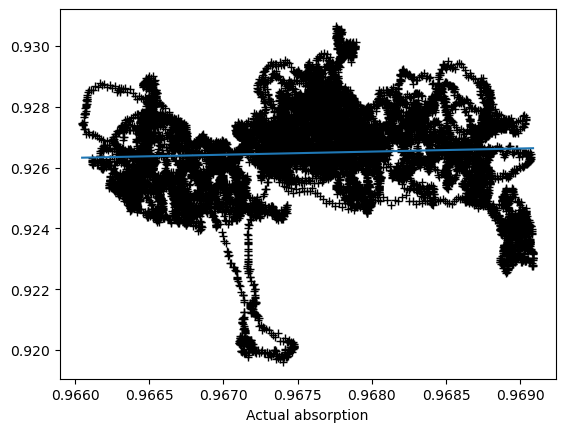

In [158]:
var,cov = curve_fit(linfit,I_ratio_ra,I_rollingavg_s)
xtest = np.linspace(np.min(I_ratio_ra),np.max(I_ratio_ra), num=10)
plt.plot(I_ratio_ra,I_rollingavg_s,'k+')
plt.plot(xtest,linfit(xtest,*var))
plt.xlabel('Predicted absorption')
plt.xlabel('Actual absorption')
print(var)